# **_EMD 相关方法_**


In [1]:
from scipy.fft import fft, ifft  # 傅里叶变换
from scipy.interpolate import UnivariateSpline  # 多项式插值
from scipy.signal import argrelextrema  # 极值点查找

import numpy as np
import random

import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 用来正常显示中文标签
plt.rcParams["axes.unicode_minus"] = False  # 用来正常显示负号

import xcw_package as xcw

from CRWU import CRWU_readdata  # CRWU数据集读写
from CRWU import CRWU_CalFCF

from EMDAnalysis import EMDAnalysis 

# 1.导入数据


In [53]:
data = CRWU_readdata("DE12K", "IR", "14", "1")

该实验转速参数:1774rpm
驱动端DE数据长度:121846
风扇端FE数据长度:121846
基座BA数据长度:121846


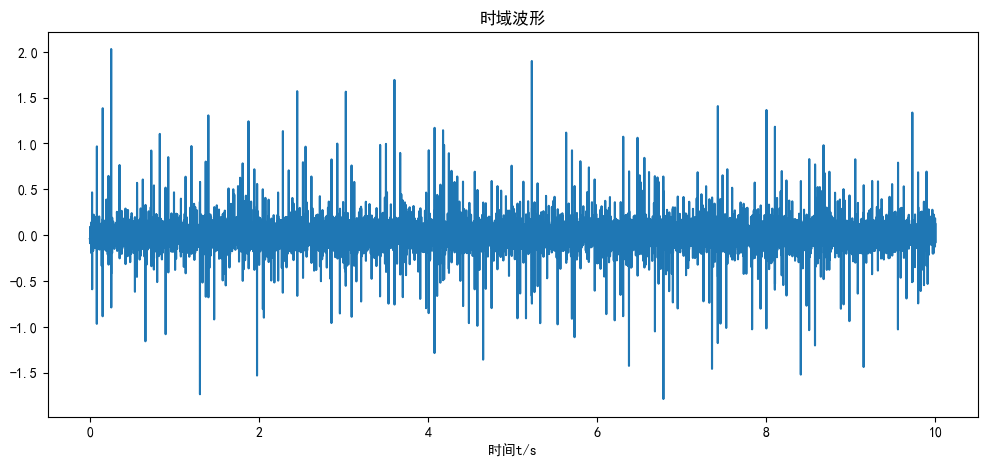

In [58]:
Sig = xcw.Signal(data["DE"], f_s=12000)
time = (0, 10)
Sig = xcw.resample(Sig, 1000, int((time[1] - time[0]) * 1000), time[0])
Sig.plot()

# 2.EMD 算法实现


EMD 分解算法


In [2]:
def extractIMF(data, dt, plot=True, **kwargs):
    max_index = argrelextrema(data, np.greater_equal)[0]
    min_index = argrelextrema(data, np.less_equal)[0]  # 查找极值点

    if max_index[0] != 0:
        max_index = np.concatenate(([0], max_index))
    if max_index[-1] != len(data) - 1:
        max_index = np.append(max_index, len(data) - 1)
    if min_index[0] != 0:
        min_index = np.concatenate(([0], min_index))
    if min_index[-1] != len(data) - 1:
        min_index = np.append(
            min_index, len(data) - 1
        )  # 添加首尾点,防止样条曲线的端点摆动

    if len(max_index) <= 3 or len(min_index) <= 3:  # 判断信号是否存在极值以进行筛选
        return None

    max_spline = UnivariateSpline(max_index, data[max_index], k=3, s=0)
    upper_envelop = max_spline(np.arange(len(data)))  # 获得上包络线

    min_spline = UnivariateSpline(min_index, data[min_index], k=3, s=0)
    lower_envelop = min_spline(np.arange(len(data)))  # 获得下包络线

    mean = (upper_envelop + lower_envelop) / 2
    result = data - mean  # 获得筛选结果

    # 绘制筛选过程
    if plot:
        time = np.arange(0, len(data) * dt, dt)
        figsize = kwargs.get("figsize", (12, 5))
        plt.figure(figsize=figsize)
        plt.plot(time, data)
        plt.plot(time[max_index], data[max_index], "ro")
        plt.plot(time[min_index], data[min_index], "go")
        plt.plot(time, upper_envelop, "r")
        plt.plot(time, lower_envelop, "g")
        plt.plot(time, mean, "b")
        plt.show()

    return result


def plot_EMD(
    s,
    decomposition_time=5,
    kappa=0.05,
    result=False,
    plot=True,
    savefig=False,
    **kwargs
):
    data = s.data.copy()  # 获取信号时序数据
    IMF = []  # IMF分量存储

    for i in range(decomposition_time):
        _h = data  # 将筛选后的残差作为新的待筛选数据

        while True:
            if plot:
                print("IMF", i + 1, "筛选中...")
            h = extractIMF(_h, s.dt, plot, **kwargs)
            if h is None:  # 无法提取IMF分量，停止筛选
                IMF.append(data)  # 此次筛选无效，将上次筛选的残差作为EMD的最终残差
                if plot:
                    print("IMF", i + 1, "筛选失败")
                break  # 筛选停止条件1
            SD = np.sum(np.square(h - _h)) / np.sum(
                np.square(h)
            )  # 计算SD，保证筛选收敛时停止
            if SD < 1e-2:
                IMF.append(h)
                break  # 筛选停止条件2
            _h = h  # 继续筛选

        data = data - IMF[-1]  # 减去新提取的IMF分量，得到残差继续筛选
        if np.sum(np.square(data)) == 0:
            break  # 最后一次筛选无效，停止分解
        elif np.sum(np.square(data)) < kappa * np.sum(np.square(s.data)):
            IMF.append(data)  # 最后一次筛选有效，将残差作为最后一个IMF分量
            if plot:
                print("残差满足条件")
            break
        elif i == decomposition_time - 1:
            IMF.append(data)  # 分解次数达到上限，将残差作为最后一个IMF分量
            if plot:
                print("分解次数达到上限")
    if plot:
        print("EMD分解完成")

    # 绘制EMD分解结果
    if plot:
        figsize = kwargs.get("figsize", None)
        if figsize is not None:
            plt.figure(figsize=(figsize[0], figsize[1] * len(IMF)))
        else:
            plt.figure(figsize=(12, 5 * len(IMF)))
        for i in range(len(IMF)):  # 按分解顺序绘制IMF分量和残差
            plt.subplot(len(IMF), 1, i + 1)
            plt.ylim(-np.max(np.abs(s.data)), np.max(np.abs(s.data)))
            if i == (len(IMF) - 1):
                plt.plot(s.t_values, IMF[i])
                plt.title("残差")
            else:
                plt.plot(s.t_values, IMF[i])
                plt.title("IMF" + str(i + 1))
        if savefig:
            plt.savefig("EMD分解结果.svg", format="svg")
        plt.show()

    IMF = np.array(IMF)
    if result:
        return IMF
    else:
        return None

EEMD 分解算法


In [59]:
def plot_EEMD(
    s,
    decomposition_time=5,
    kappa=0.05,
    Ensemble_time=10,
    noise_level=0.1,
    result=False,
    plot=True,
    savefig=False,
    **kwargs
):
    data = s.data.copy()  # 获取信号时序数据
    IMFs = np.zeros((decomposition_time + 1, s.N))  # EEMD分解平均结果

    for j in range(Ensemble_time):
        IMF = []  # IMF分量存储
        data = s.data.copy() + noise_level * np.random.randn(s.N)  # 添加高斯白噪声

        # 单次EMD分解
        for i in range(decomposition_time):
            _h = data  # 将筛选后的残差作为新的待筛选数据
            while True:
                h = extractIMF(_h, s.dt, plot=False, **kwargs)
                if h is None:  # 无法提取IMF分量，停止筛选
                    IMF.append(data)  # 此次筛选无效，将上次筛选的残差作为EMD的最终残差
                    break  # 筛选停止条件1
                SD = np.sum(np.square(h - _h)) / np.sum(
                    np.square(h)
                )  # 计算SD，保证筛选收敛时停止
                if SD < 1e-2:
                    IMF.append(h)
                    break  # 筛选停止条件2
                _h = h  # 继续筛选
            data = data - IMF[-1]  # 减去新提取的IMF分量，得到残差继续筛选
            if np.sum(np.square(data)) == 0:
                break  # 最后一次筛选无效，停止分解
            elif np.sum(np.square(data)) < kappa * np.sum(np.square(s.data)):
                IMF.append(data)  # 最后一次筛选有效，将残差作为最后一个IMF分量
                break
            elif i == decomposition_time - 1:
                IMF.append(data)  # 分解次数达到上限，将残差作为最后一个IMF分量

        IMF = np.array(IMF)
        # 对齐IMF个数
        if len(IMF) < decomposition_time + 1:
            IMF = np.concatenate(
                (IMF, np.zeros((decomposition_time + 1 - len(IMF), s.N))), axis=0
            )
        IMFs += IMF  # 累加IMF分量

    IMFs = IMFs / Ensemble_time  # 求平均

    # 绘制EEMD分解结果
    if plot:
        figsize = kwargs.get("figsize", None)
        if figsize is not None:
            plt.figure(figsize=(figsize[0], figsize[1] * len(IMFs)))
        else:
            plt.figure(figsize=(12, 5 * len(IMFs)))
        xlim = kwargs.get("xlim", None)
        if xlim is not None:
            plt.xlim(xlim[0], xlim[1])
        ylim = kwargs.get("ylim", None)
        if ylim is not None:
            plt.ylim(ylim[0], ylim[1])
        for i in range(len(IMFs)):  # 按分解顺序绘制IMF分量和残差
            plt.subplot(len(IMFs), 1, i + 1)
            if i == (len(IMFs) - 1):
                plt.plot(s.t_values, IMFs[i])
                plt.title("残差")
            else:
                plt.plot(s.t_values, IMFs[i])
                plt.title("IMF" + str(i + 1))
        if savefig:
            plt.savefig("EEMD分解结果.svg", format="svg")
        plt.show()

    if result:
        return IMFs
    else:
        return None

Hilbert 谱算法


In [3]:
def Hilbert(x):
    fft_x = fft(x)
    positive = fft_x[: len(fft_x) // 2] * 2  # 取正部乘2
    negative = fft_x[len(fft_x) // 2 :] * 0  # 取负部乘0
    fft_s = np.concatenate((positive, negative))  # 得解析信号的频谱
    fft_s[0] = fft_x[0]
    hat_x = np.imag(ifft(fft_s))  # 取解析信号的虚部得到原始信号的希尔伯特变换
    return hat_x


def plot_Hilbertspectrum(data, dt, result=False, plot=True, savefig=False, **kwargs):
    IMF = data.copy()
    N = IMF.shape[1]
    amp = np.zeros_like(IMF)
    fre = np.zeros_like(IMF)

    for i, imf in enumerate(IMF):
        analytic = imf + Hilbert(imf) * 1j  # 得到解析信号
        amp[i] = np.abs(analytic)  # 得到幅度
        phase = np.unwrap(np.angle(analytic))
        fre[i] = np.gradient(phase, dt) / (2 * np.pi)  # 得到瞬时频率

    fre_bins = np.arange(0, 1 / (5 * dt), 1 / (N * dt))  # 离散频率轴
    fre = (np.digitize(fre, fre_bins) - 1) * (
        fre_bins[1]
    )  # 将计算得到的连续瞬时频率离散化
    time = np.linspace(0, N * dt, N, endpoint=False)
    times = np.tile(time, (IMF.shape[0], 1))  # 生成离散时间轴

    # 绘制希尔伯特谱-时频幅值图
    if plot:
        figsize = kwargs.get("figsize", (8, 6))
        plt.figure(figsize=figsize)
        plt.scatter(times, fre, c=amp, cmap="jet", s=0.1)
        plt.colorbar()
        plt.xlabel("时间t/s")
        plt.ylabel("频率f/Hz")
        xlim = kwargs.get("xlim", None)
        if xlim is not None:
            plt.xlim(xlim[0], xlim[1])
        ylim = kwargs.get("ylim", None)
        if ylim is not None:
            plt.ylim(ylim[0], ylim[1])
        title = kwargs.get("title", "希尔伯特谱-时频散点图")
        plt.title(title)
        if savefig:
            plt.savefig("希尔伯特谱-时频散点图.svg", format="svg")
        plt.show()

    if result:
        H = np.zeros((len(fre_bins), len(time)))  # 根据离散频率、时间轴生成时频幅值矩阵
        for f, t, a in zip(
            fre.ravel(), times.ravel(), amp.ravel()
        ):  # 遍历所有IMF的时频幅值数据
            H[int(f // (fre_bins[1]))][
                int(t // (time[1]))
            ] += a  # 将时频幅值数据填入矩阵对应点，如果有多个数据填入同一点则累加幅值
        return fre_bins, time, H
    else:
        return None


def plot_HTmarginalspectra(f, t, H, result=False, plot=True, savefig=False, **kwargs):
    H_f = np.sum(H, axis=1) * t[1]  # 对希尔伯特谱时间轴积分得到边际谱

    # 绘制边际谱
    if plot:
        figsize = kwargs.get("figsize", (12, 5))
        plt.figure(figsize=figsize)
        plt.plot(f, H_f)
        plt.xlabel("频率f/Hz")
        xlim = kwargs.get("xlim", None)
        if xlim is not None:
            plt.xlim(xlim[0], xlim[1])
        ylim = kwargs.get("ylim", None)
        if ylim is not None:
            plt.ylim(ylim[0], ylim[1])
        title = kwargs.get("title", "希尔伯特边际谱")
        plt.title(title)
        if savefig:
            plt.savefig("希尔伯特边际谱.svg", format="svg")
        plt.show()

    if result:
        return H_f
    else:
        return None


def plot_Degstationary(f, t, H, result=False, plot=True, savefig=False, **kwargs):
    difference = np.var(H, axis=1)  # 计算每一频率成分幅值分布的方差
    m = np.mean(H, axis=1)  # 计算每一频率成分幅值分布的均值
    m = np.where(m == 0, 1, m)  # 避免除零错误
    DS = difference / m**2  # 计算归一化平稳度谱

    # 绘制平稳度谱
    if plot:
        figsize = kwargs.get("figsize", (12, 5))
        plt.figure(figsize=figsize)
        plt.plot(f, DS)
        plt.xlabel("频率f/Hz")
        xlim = kwargs.get("xlim", None)
        if xlim is not None:
            plt.xlim(xlim[0], xlim[1])
        ylim = kwargs.get("ylim", None)
        if ylim is not None:
            plt.ylim(ylim[0], ylim[1])
        title = kwargs.get("title", "希尔伯特平稳度谱")
        plt.title(title)
        if savefig:
            plt.savefig("希尔伯特平稳度谱.svg", format="svg")
        plt.show()

    if result:
        return DS
    else:
        return None

数据降采样平滑算法


In [13]:
def smoothing(data, kernel):
    return np.convolve(data, kernel, mode="same")


def lowsmoothing(data, size, axis):
    s = lambda x: smoothing(x, kernel=np.ones(size) / size)  # 定义平滑函数
    smoothing_data = np.apply_along_axis(s, axis, data)  # 平滑
    # 创建一个切片元组
    slice_tuple = [slice(None)] * data.ndim
    slice_tuple[axis] = slice(None, None, size)
    # 使用切片进行降采样
    downsampled_data = smoothing_data[tuple(slice_tuple)]
    return downsampled_data

# 3.算法测试


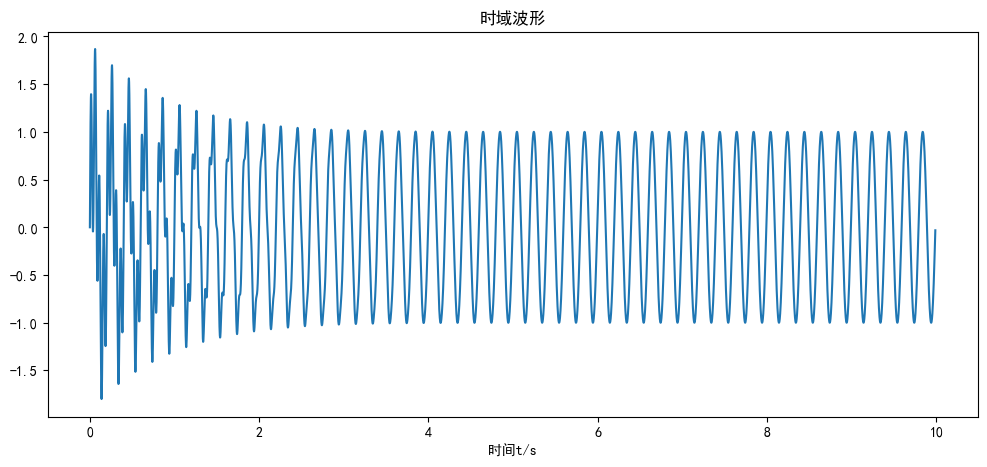

In [3]:
t = np.arange(0, 10, 1 / 1000)
x = np.sin(2*np.pi*5*t) + np.sin(2*np.pi*20*t)*np.exp(-t)
Sig = xcw.Signal(x, f_s=1000)
Sig.plot()

In [4]:
IMFs = plot_EMD(Sig, decomposition_time=10, kappa=0.01, result=True,plot=False)

In [ ]:
f, t, H = plot_Hilbertspectrum(IMFs, Sig.dt, result=True)

In [ ]:
plot_HTmarginalspectra(f, t, H, ylim=(0, 0.5))

**模态混叠(mode mixing)**:一个 IMF 包含不同特征时间尺度的振荡模式，或者多个 IMF 包含相同特征时间尺度的振荡模式  
可能的原因：

1. We have decided to adopt the time lapse between successive extrema as the definition of the  
   time scale for the intrinsic oscillatory mode
2. the process is indeed like sifting: to separate the finest local mode from the data first  
   based only on the characteristic time scale

EMD 通过极值点间隔来表征信号的振荡时间尺度，并在分解中凭借该特征局部地筛选出最细尺度振荡模式组成 IMF。  
由于这种局部筛选的特性，使得当振荡模式本身存在间歇现象时，容易造成不同尺度的 IMF 间的混叠
